In [1]:
from google.colab import files
uploaded = files.upload()

Saving caffe.csv to caffe.csv
Saving incubator-mxnet.csv to incubator-mxnet.csv
Saving keras.csv to keras.csv
Saving pytorch.csv to pytorch.csv
Saving tensorflow.csv to tensorflow.csv


In [2]:
import pandas as pd

df = pd.read_csv("caffe.csv")
df.head()

,Unnamed: 0,Repository,Number,State,Title,Body,Labels,Comments,Codes,Commands,class,related
0,0,caffe,3075,closed,strange result when running blvc_reference_caf...,"Hi,\n\nI tried to run the example here: https:...",NaN,"[""You need to do\nout['prob'].argmax(axis=1)\n...",[],[],1,0
1,1,caffe,4102,closed,Change the batch_size by the method Reshape(),I used a deploy.prototxt to initialize a new n...,NaN,['One probably reason I found in the code is :...,"['\ninput: ""data""\ninput_shape {\n dim: 256\n...",[],1,0
2,2,caffe,5643,open,Convert caffemodel into C++/python scripts to ...,"Hi all, I have a question to discuss with anyo...",NaN,"[""No that won't help you get more speed. The C...",[],[],1,0
3,3,caffe,3086,closed,PyCaffe backward() produces zero gradients whe...,I'm working on generating saliency maps though...,NaN,"[""Closing as there is not enough information h...","[""\nimport caffe\nimport numpy as np\ncaffe.se...",[],1,0
4,4,caffe,2448,closed,CPU usage at a low level,Hi everyone. When I run Caffe with CPU usage c...,NaN,"[""@bearpaw Hey dude, are you using CPU only? M...",['\nI0512 22:09:43.043788 7012 caffe.cpp:273]...,[],1,0


In [3]:
df.shape

(286, 12)

In [4]:
df.columns

Index(['Unnamed: 0', 'Repository', 'Number', 'State', 'Title', 'Body',
       'Labels', 'Comments', 'Codes', 'Commands', 'class', 'related'],
      dtype='object')

In [5]:
df[["Title", "Body", "related"]].isnull().sum()

,0
Title,0
Body,5
related,0


In [6]:
df["Title"] = df["Title"].fillna("")
df["Body"] = df["Body"].fillna("")
df["text"] = df["Title"] + " " + df["Body"]

df[["Title", "Body", "text", "related"]].head()


,Title,Body,text,related
0,strange result when running blvc_reference_caf...,"Hi,\n\nI tried to run the example here: https:...",strange result when running blvc_reference_caf...,0
1,Change the batch_size by the method Reshape(),I used a deploy.prototxt to initialize a new n...,Change the batch_size by the method Reshape() ...,0
2,Convert caffemodel into C++/python scripts to ...,"Hi all, I have a question to discuss with anyo...",Convert caffemodel into C++/python scripts to ...,0
3,PyCaffe backward() produces zero gradients whe...,I'm working on generating saliency maps though...,PyCaffe backward() produces zero gradients whe...,0
4,CPU usage at a low level,Hi everyone. When I run Caffe with CPU usage c...,CPU usage at a low level Hi everyone. When I r...,0


In [7]:
df["related"].value_counts()

,count
related,
0,282
1,4


In [8]:
X = df["text"]
y = df["related"]

print(X.head())
print()
print(y.head())


0    strange result when running blvc_reference_caf...
1    Change the batch_size by the method Reshape() ...
2    Convert caffemodel into C++/python scripts to ...
3    PyCaffe backward() produces zero gradients whe...
4    CPU usage at a low level Hi everyone. When I r...
Name: text, dtype: object

0    0
1    0
2    0
3    0
4    0
Name: related, dtype: int64


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print()
print("Training label counts:")
print(y_train.value_counts())
print()
print("Testing label counts:")
print(y_test.value_counts())


Training samples: 200
Testing samples: 86

Training label counts:
related
0    197
1      3
Name: count, dtype: int64

Testing label counts:
related
0    85
1     1
Name: count, dtype: int64


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

baseline_model = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("nb", MultinomialNB())
])

baseline_model.fit(X_train, y_train)
baseline_predictions = baseline_model.predict(X_test)

print(baseline_predictions[:20])


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

print("Precision:", precision_score(y_test, baseline_predictions, zero_division=0))
print("Recall:", recall_score(y_test, baseline_predictions, zero_division=0))
print("F1-score:", f1_score(y_test, baseline_predictions, zero_division=0))

print("\nDetailed Report:\n")
print(classification_report(y_test, baseline_predictions, zero_division=0))


Precision: 0.0
Recall: 0.0
F1-score: 0.0

Detailed Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99        85
           1       0.00      0.00      0.00         1

    accuracy                           0.99        86
   macro avg       0.49      0.50      0.50        86
weighted avg       0.98      0.99      0.98        86



In [12]:
from sklearn.linear_model import LogisticRegression

improved_model = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("lr", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

improved_model.fit(X_train, y_train)
improved_predictions = improved_model.predict(X_test)

print(improved_predictions[:20])


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [13]:
print("Precision:", precision_score(y_test, improved_predictions, zero_division=0))
print("Recall:", recall_score(y_test, improved_predictions, zero_division=0))
print("F1-score:", f1_score(y_test, improved_predictions, zero_division=0))

print("\nDetailed Report:\n")
print(classification_report(y_test, improved_predictions, zero_division=0))


Precision: 0.0
Recall: 0.0
F1-score: 0.0

Detailed Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99        85
           1       0.00      0.00      0.00         1

    accuracy                           0.99        86
   macro avg       0.49      0.50      0.50        86
weighted avg       0.98      0.99      0.98        86



In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_file(file_name):
    df = pd.read_csv(file_name)

    df["Title"] = df["Title"].fillna("")
    df["Body"] = df["Body"].fillna("")
    df["text"] = df["Title"] + " " + df["Body"]

    X = df["text"]
    y = df["related"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )

    baseline_model = Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english")),
        ("nb", MultinomialNB())
    ])

    improved_model = Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english")),
        ("lr", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ])

    baseline_model.fit(X_train, y_train)
    baseline_predictions = baseline_model.predict(X_test)

    improved_model.fit(X_train, y_train)
    improved_predictions = improved_model.predict(X_test)

    result = {
        "file": file_name,
        "total_rows": len(df),
        "positive_count": int(y.sum()),
        "baseline_precision": precision_score(y_test, baseline_predictions, zero_division=0),
        "baseline_recall": recall_score(y_test, baseline_predictions, zero_division=0),
        "baseline_f1": f1_score(y_test, baseline_predictions, zero_division=0),
        "improved_precision": precision_score(y_test, improved_predictions, zero_division=0),
        "improved_recall": recall_score(y_test, improved_predictions, zero_division=0),
        "improved_f1": f1_score(y_test, improved_predictions, zero_division=0),
    }

    return result


In [15]:
files = [
    "caffe.csv",
    "incubator-mxnet.csv",
    "keras.csv",
    "pytorch.csv",
    "tensorflow.csv"
]

results = []

for file_name in files:
    result = evaluate_file(file_name)
    results.append(result)

results_df = pd.DataFrame(results)
results_df


,file,total_rows,positive_count,baseline_precision,baseline_recall,baseline_f1,improved_precision,improved_recall,improved_f1
0,caffe.csv,286,4,0.0,0.0,0.0,0.00,0.000000,0.000000
1,incubator-mxnet.csv,516,13,0.0,0.0,0.0,0.50,0.250000,0.333333
2,keras.csv,668,7,0.0,0.0,0.0,0.00,0.000000,0.000000
3,pytorch.csv,752,19,0.0,0.0,0.0,0.00,0.000000,0.000000
4,tensorflow.csv,1490,37,0.0,0.0,0.0,0.25,0.181818,0.210526


In [16]:
import numpy as np

def evaluate_file_repeated(file_name, repeats=30):
    df = pd.read_csv(file_name)

    df["Title"] = df["Title"].fillna("")
    df["Body"] = df["Body"].fillna("")
    df["text"] = df["Title"] + " " + df["Body"]

    X = df["text"]
    y = df["related"]

    baseline_f1_scores = []
    improved_f1_scores = []

    baseline_precision_scores = []
    baseline_recall_scores = []

    improved_precision_scores = []
    improved_recall_scores = []

    for seed in range(repeats):
        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=0.30,
            random_state=seed,
            stratify=y
        )

        baseline_model = Pipeline([
            ("tfidf", TfidfVectorizer(stop_words="english")),
            ("nb", MultinomialNB())
        ])

        improved_model = Pipeline([
            ("tfidf", TfidfVectorizer(stop_words="english")),
            ("lr", LogisticRegression(max_iter=1000, class_weight="balanced"))
        ])

        baseline_model.fit(X_train, y_train)
        baseline_predictions = baseline_model.predict(X_test)

        improved_model.fit(X_train, y_train)
        improved_predictions = improved_model.predict(X_test)

        baseline_precision_scores.append(
            precision_score(y_test, baseline_predictions, zero_division=0)
        )
        baseline_recall_scores.append(
            recall_score(y_test, baseline_predictions, zero_division=0)
        )
        baseline_f1_scores.append(
            f1_score(y_test, baseline_predictions, zero_division=0)
        )

        improved_precision_scores.append(
            precision_score(y_test, improved_predictions, zero_division=0)
        )
        improved_recall_scores.append(
            recall_score(y_test, improved_predictions, zero_division=0)
        )
        improved_f1_scores.append(
            f1_score(y_test, improved_predictions, zero_division=0)
        )

    result = {
        "file": file_name,
        "total_rows": len(df),
        "positive_count": int(y.sum()),
        "baseline_precision_mean": np.mean(baseline_precision_scores),
        "baseline_recall_mean": np.mean(baseline_recall_scores),
        "baseline_f1_mean": np.mean(baseline_f1_scores),
        "improved_precision_mean": np.mean(improved_precision_scores),
        "improved_recall_mean": np.mean(improved_recall_scores),
        "improved_f1_mean": np.mean(improved_f1_scores),
        "baseline_f1_scores": baseline_f1_scores,
        "improved_f1_scores": improved_f1_scores
    }

    return result


In [17]:
repeated_results = []

for file_name in files:
    result = evaluate_file_repeated(file_name, repeats=30)
    repeated_results.append(result)

repeated_results_df = pd.DataFrame(repeated_results)

repeated_results_df[[
    "file",
    "total_rows",
    "positive_count",
    "baseline_precision_mean",
    "baseline_recall_mean",
    "baseline_f1_mean",
    "improved_precision_mean",
    "improved_recall_mean",
    "improved_f1_mean"
]]


,file,total_rows,positive_count,baseline_precision_mean,baseline_recall_mean,baseline_f1_mean,improved_precision_mean,improved_recall_mean,improved_f1_mean
0,caffe.csv,286,4,0.0,0.0,0.0,0.000000,0.000000,0.000000
1,incubator-mxnet.csv,516,13,0.0,0.0,0.0,0.375000,0.133333,0.188016
2,keras.csv,668,7,0.0,0.0,0.0,0.000000,0.000000,0.000000
3,pytorch.csv,752,19,0.0,0.0,0.0,0.045267,0.044444,0.043476
4,tensorflow.csv,1490,37,0.0,0.0,0.0,0.226044,0.200000,0.204399


In [18]:
from scipy.stats import wilcoxon

for result in repeated_results:
    file_name = result["file"]
    baseline_scores = result["baseline_f1_scores"]
    improved_scores = result["improved_f1_scores"]

    try:
        stat, p_value = wilcoxon(improved_scores, baseline_scores)
        print(f"{file_name}: statistic={stat}, p-value={p_value}")
    except ValueError as e:
        print(f"{file_name}: Wilcoxon test could not be computed -> {e}")


caffe.csv: statistic=0.0, p-value=nan
incubator-mxnet.csv: statistic=0.0, p-value=0.00034991290274753197
keras.csv: statistic=0.0, p-value=nan
pytorch.csv: statistic=0.0, p-value=0.01755232593841686
tensorflow.csv: statistic=0.0, p-value=2.5407267893620098e-06


/usr/local/lib/python3.12/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


In [19]:
final_results = repeated_results_df[[
    "file",
    "positive_count",
    "baseline_precision_mean",
    "baseline_recall_mean",
    "baseline_f1_mean",
    "improved_precision_mean",
    "improved_recall_mean",
    "improved_f1_mean"
]].copy()

final_results = final_results.round(4)
final_results


,file,positive_count,baseline_precision_mean,baseline_recall_mean,baseline_f1_mean,improved_precision_mean,improved_recall_mean,improved_f1_mean
0,caffe.csv,4,0.0,0.0,0.0,0.0000,0.0000,0.0000
1,incubator-mxnet.csv,13,0.0,0.0,0.0,0.3750,0.1333,0.1880
2,keras.csv,7,0.0,0.0,0.0,0.0000,0.0000,0.0000
3,pytorch.csv,19,0.0,0.0,0.0,0.0453,0.0444,0.0435
4,tensorflow.csv,37,0.0,0.0,0.0,0.2260,0.2000,0.2044


In [20]:
final_results.to_csv("final_results_summary.csv", index=False)
print("Saved final_results_summary.csv")


Saved final_results_summary.csv


In [21]:
p_values = []

for result in repeated_results:
    file_name = result["file"]
    baseline_scores = result["baseline_f1_scores"]
    improved_scores = result["improved_f1_scores"]

    try:
        stat, p_value = wilcoxon(improved_scores, baseline_scores)
    except ValueError:
        p_value = None

    p_values.append({
        "file": file_name,
        "p_value": p_value
    })

p_values_df = pd.DataFrame(p_values)
p_values_df


/usr/local/lib/python3.12/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


,file,p_value
0,caffe.csv,NaN
1,incubator-mxnet.csv,0.000350
2,keras.csv,NaN
3,pytorch.csv,0.017552
4,tensorflow.csv,0.000003


In [22]:
report_table = final_results.merge(p_values_df, on="file", how="left")
report_table = report_table.round(4)
report_table


,file,positive_count,baseline_precision_mean,baseline_recall_mean,baseline_f1_mean,improved_precision_mean,improved_recall_mean,improved_f1_mean,p_value
0,caffe.csv,4,0.0,0.0,0.0,0.0000,0.0000,0.0000,NaN
1,incubator-mxnet.csv,13,0.0,0.0,0.0,0.3750,0.1333,0.1880,0.0003
2,keras.csv,7,0.0,0.0,0.0,0.0000,0.0000,0.0000,NaN
3,pytorch.csv,19,0.0,0.0,0.0,0.0453,0.0444,0.0435,0.0176
4,tensorflow.csv,37,0.0,0.0,0.0,0.2260,0.2000,0.2044,0.0000


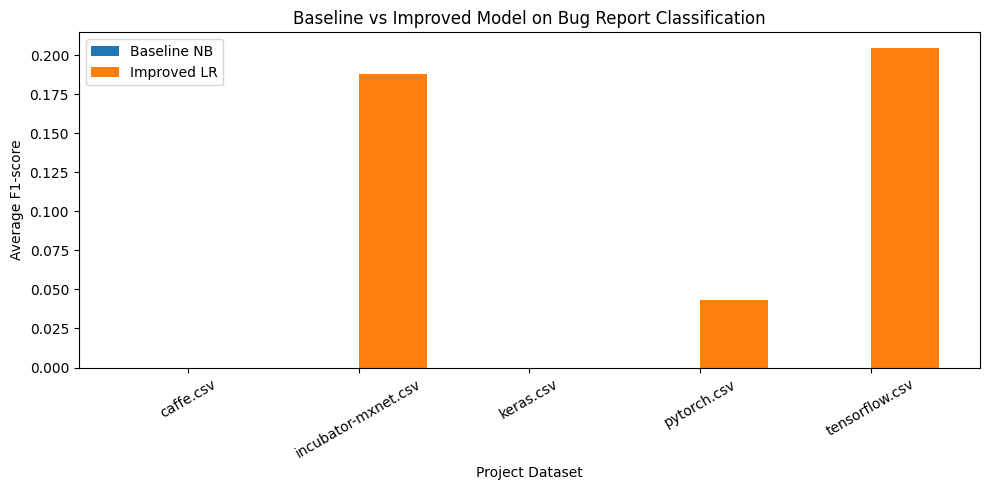

In [23]:
import matplotlib.pyplot as plt

plot_df = report_table.copy()

plt.figure(figsize=(10, 5))
x = range(len(plot_df))

plt.bar([i - 0.2 for i in x], plot_df["baseline_f1_mean"], width=0.4, label="Baseline NB")
plt.bar([i + 0.2 for i in x], plot_df["improved_f1_mean"], width=0.4, label="Improved LR")

plt.xticks(list(x), plot_df["file"], rotation=30)
plt.ylabel("Average F1-score")
plt.xlabel("Project Dataset")
plt.title("Baseline vs Improved Model on Bug Report Classification")
plt.legend()
plt.tight_layout()
plt.show()
